<a href="https://colab.research.google.com/github/Neeraj-P-Raju/AIML-internship/blob/main/Day4_internship(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import pandas as pd
file_path = '/content/preprocessing_practice_dataset.csv'
employee_data = pd.read_csv(file_path)

numerical_columns = ['Age']
employee_data.dropna(subset=numerical_columns, inplace=True)

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

employee_data['Age_MinMax'] = minmax_scaler.fit_transform(employee_data[['Age']])

employee_data['Age_Standard'] = standard_scaler.fit_transform(employee_data[['Age']])

employee_data[['Age', 'Age_MinMax', 'Age_Standard']].head()

,Age,Age_MinMax,Age_Standard
0,59.0,1.000000,1.746756
1,49.0,0.736842,0.833817
2,35.0,0.368421,-0.444297
3,28.0,0.184211,-1.083354
4,41.0,0.526316,0.103466


/tmp/ipykernel_1085/1544492395.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=employee_data,x='Attrition',y='Age',palette='plasma')


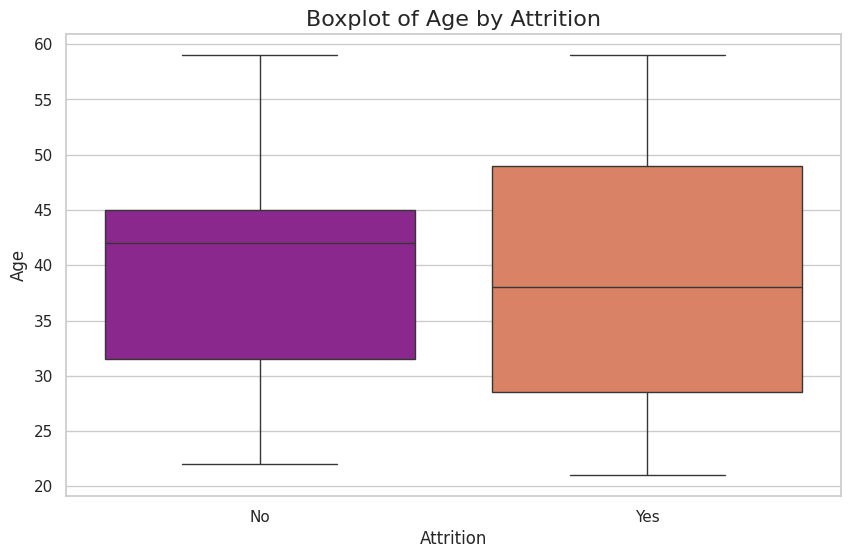

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.boxplot(data=employee_data,x='Attrition',y='Age',palette='plasma')

plt.title('Boxplot of Age by Attrition',fontsize=16)
plt.xlabel('Attrition',fontsize=12)
plt.ylabel('Age',fontsize=12)
plt.show()

/tmp/ipykernel_1085/739427882.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=employee_data,x='Education',y='Experience_Years',palette='YlGnBu')


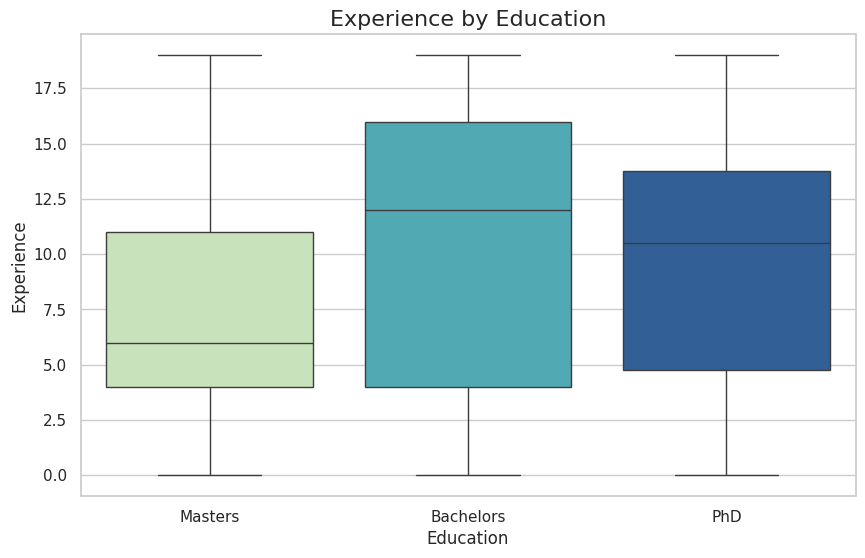

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.boxplot(data=employee_data,x='Education',y='Experience_Years',palette='YlGnBu')

plt.title('Experience by Education',fontsize=16)
plt.xlabel('Education',fontsize=12)
plt.ylabel('Experience',fontsize=12)
plt.show()

In [14]:
employee_data[['Age','Gender','Education','Experience_Years','Monthly_Salary','Performance_Rating','City','Attrition']]

,Age,Gender,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition
0,59.0,Male,Masters,18,52350.0,5,Calicut,No
1,49.0,Female,Bachelors,16,118008.0,2,Chennai,Yes
2,35.0,Female,NaN,19,119297.0,1,Kochi,Yes
3,28.0,Female,PhD,9,50351.0,2,Trivandrum,Yes
4,41.0,Male,Bachelors,5,113668.0,3,Trivandrum,Yes
...,...,...,...,...,...,...,...,...
95,54.0,Female,Masters,11,48625.0,5,Chennai,Yes
96,53.0,Male,Masters,13,107873.0,5,Trivandrum,Yes
97,43.0,Male,PhD,1,97592.0,3,Chennai,No
98,44.0,Female,PhD,18,102052.0,5,Calicut,Yes


In [17]:
numerical_features=employee_data.select_dtypes(include=['float64','int64'])
skewness=numerical_features.skew().sort_values(ascending=False)
print("Skewness of Numerical Features:")
print(skewness)

Skewness of Numerical Features:
Age                   0.035232
Age_Standard          0.035232
Age_MinMax            0.035232
Experience_Years      0.022247
Employee_ID          -0.057775
Monthly_Salary       -0.077529
Performance_Rating   -0.300790
dtype: float64


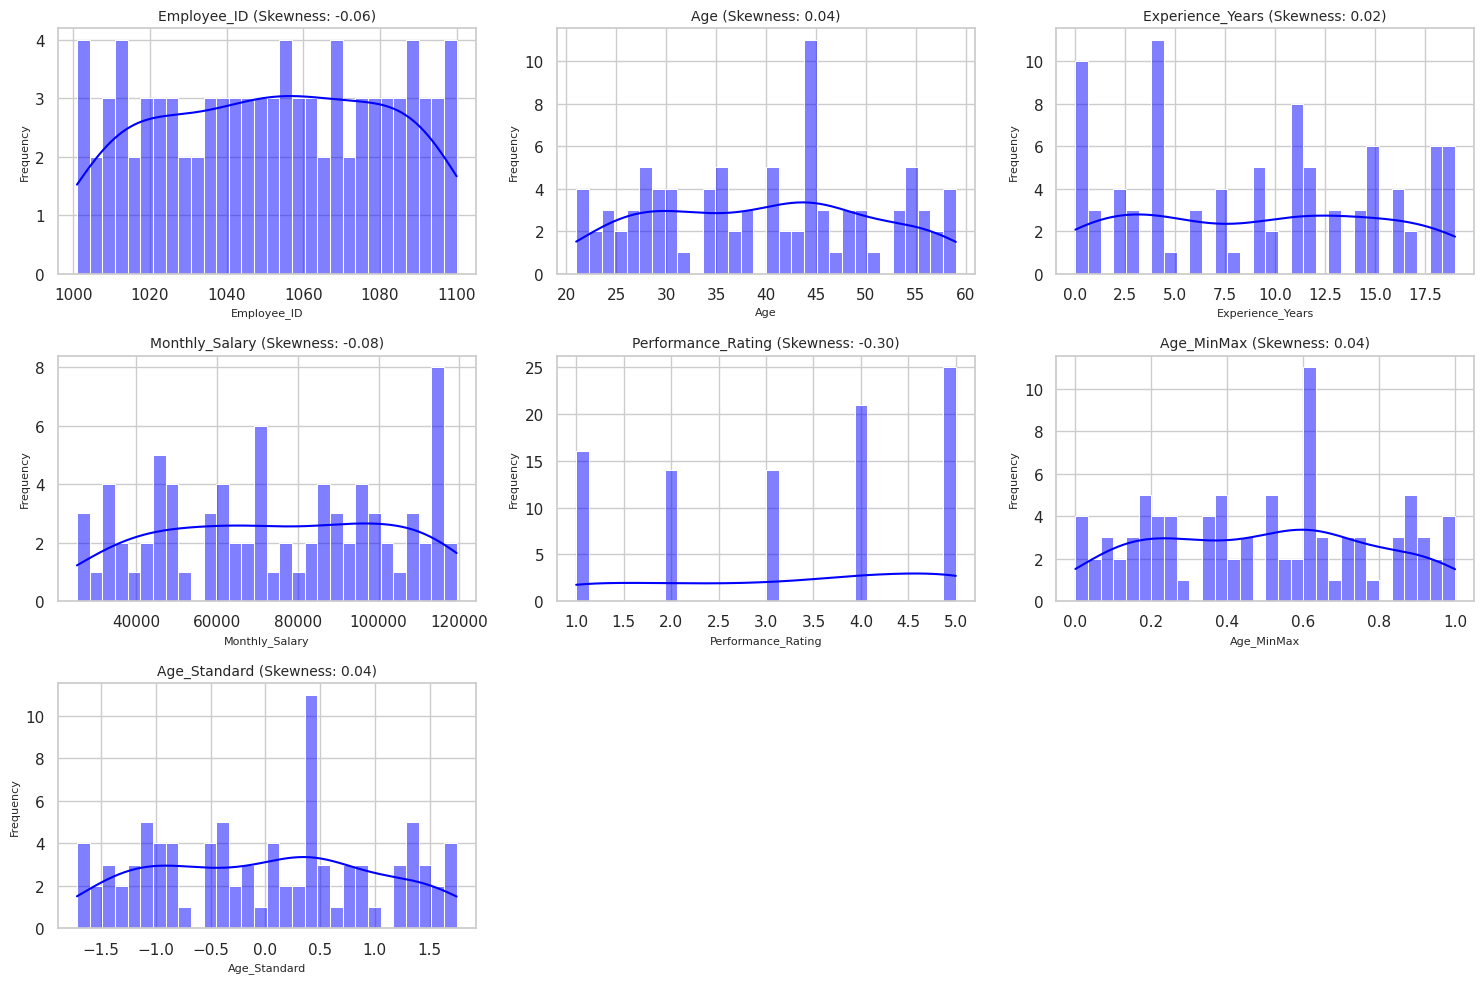

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_features.columns, 1):
    plt.subplot((len(numerical_features.columns) // 3) + 1, 3, i)
    sns.histplot(employee_data[column].dropna(), kde=True, bins=30, color='blue')
    plt.title(f'{column} (Skewness: {skewness[column]:.2f})', fontsize=10)
    plt.xlabel(column, fontsize=8)
    plt.ylabel('Frequency', fontsize=8)

plt.tight_layout()
plt.show()

<Axes: xlabel='City'>

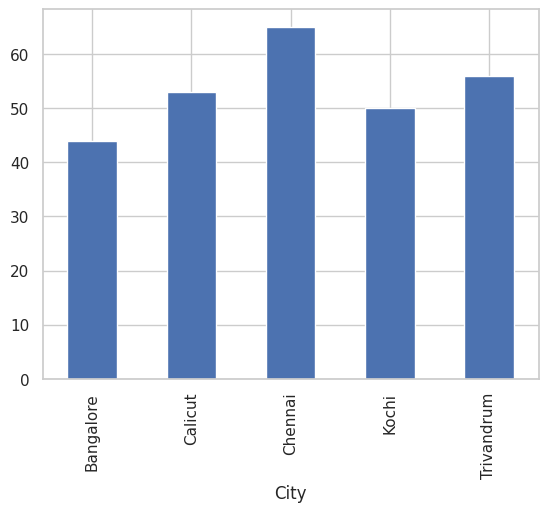

In [33]:
City_pay = employee_data.groupby('City')['Performance_Rating'].sum()
City_pay
City_pay.plot(kind='bar')

<Axes: xlabel='City'>

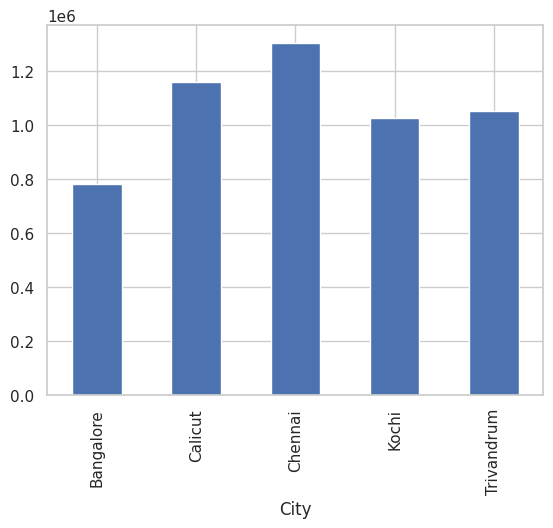

In [34]:
City_pay = employee_data.groupby('City')['Monthly_Salary'].sum()
City_pay
City_pay.plot(kind='bar')

<Axes: xlabel='City'>

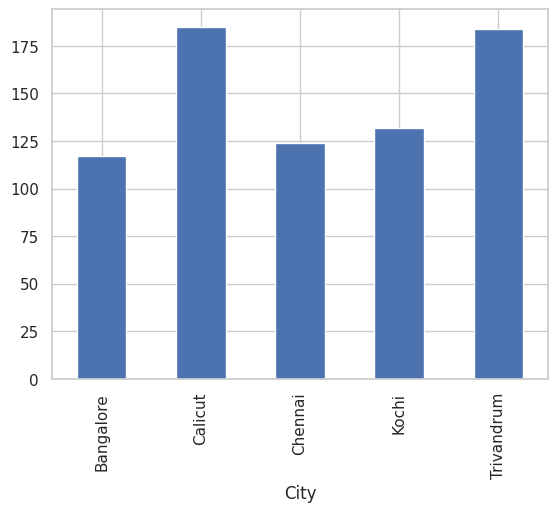

In [35]:
City_pay = employee_data.groupby('City')['Experience_Years'].sum()
City_pay
City_pay.plot(kind='bar')

/tmp/ipykernel_1085/3898223417.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=employee_data,x='Education',y='Department',palette='YlGnBu')


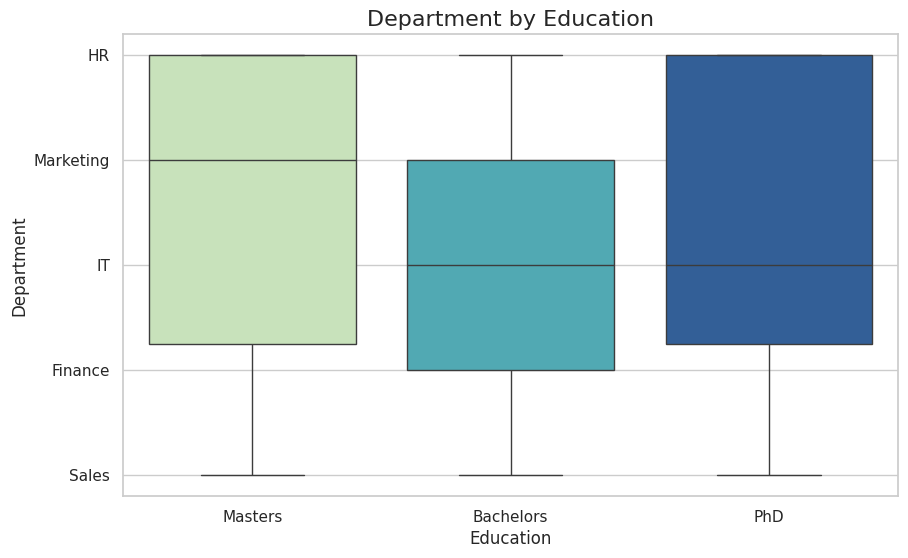

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.boxplot(data=employee_data,x='Education',y='Department',palette='YlGnBu')

plt.title('Department by Education',fontsize=16)
plt.xlabel('Education',fontsize=12)
plt.ylabel('Department',fontsize=12)
plt.show()

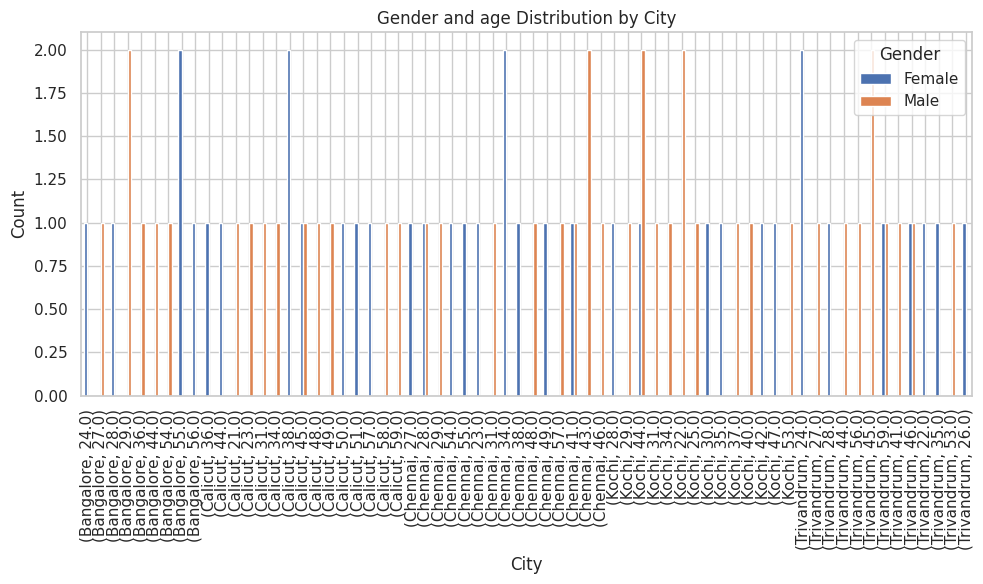

In [48]:
City_gender_counts = employee_data.groupby(['City','Age'])['Gender'].value_counts().unstack(fill_value=0)
City_gender_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Gender and age Distribution by City')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [50]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
employee_data = pd.read_csv('/content/preprocessing_practice_dataset.csv')
employee_data

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes
...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes
97,1098,43.0,Male,NaN,PhD,1,97592.0,3,Chennai,No
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes


In [53]:
from sklearn.preprocessing import LabelEncoder

encoded_data = employee_data.copy()
label_encoder= LabelEncoder()

for column in ['Gender', 'Department', 'Education', 'City', 'Attrition']:
    if column in encoded_data.columns:
        encoded_data[column] = label_encoder.fit_transform(encoded_data[column].astype(str))

display(encoded_data.head())

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition
0,1001,59.0,1,1,1,18,52350.0,5,1,0
1,1002,49.0,0,3,0,16,118008.0,2,2,1
2,1003,35.0,0,1,3,19,119297.0,1,3,1
3,1004,28.0,0,1,2,9,50351.0,2,4,1
4,1005,41.0,1,2,0,5,113668.0,3,4,1
